# YOLOv8

Training YOLOv8 to detect traffic signs in an image.

## Setup

In [42]:
import os
import yaml
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings
from PIL import Image

In [3]:
%matplotlib inline

In [3]:
# define the model name
model_name = 'yolov8n.pt'

In [4]:
device = 0 if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


### TensorBoard

In [5]:
settings.update({'tensorboard': True})

In [6]:
%reload_ext tensorboard
%tensorboard --logdir runs --port 6007

Reusing TensorBoard on port 6007 (pid 23308), started 10:11:01 ago. (Use '!kill 23308' to kill it.)

## Prepare Dataset

In [19]:
# dataset paths
DATASET_ROOT = os.path.join('Dataset', 'Train-Test-Val Split')                # dataset
YOLO_YAML_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO', 'data.yaml') # data.yaml file to be used by model
YOLO_DATA_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO')              # general yolo dataset - images, labels, data.yaml

In [8]:
# Correct the yaml paths for current user:
# Load the current yaml
with open(YOLO_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)
    
# Update the paths
data['path'] = os.path.abspath(YOLO_DATA_PATH)
data['train'] = os.path.join(data['path'], 'images', 'train')
data['val'] = os.path.join(data['path'], 'images', 'val')
data['test'] = os.path.join(data['path'], 'images', 'test')

# Save the updated yaml
with open(YOLO_YAML_PATH, 'w') as f:
    yaml.safe_dump(data, f, width=float('inf'))
    
print(f'Updated YAML paths in {YOLO_YAML_PATH}')

Updated YAML paths in Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml


In [9]:
# confirm paths are correct
print(data)

{'names': {0: 'Blind-Spot Mirror (Convex)', 1: 'No Entry (One Way)', 2: 'No Through Road (T-Sign)', 3: 'Pedestrian Crossing', 4: 'Roundabout Ahead', 5: 'Stop'}, 'path': 'C:\\Users\\spite\\Desktop\\ARI3129 Advanced Computer Vision for Artificial Intelligence\\Assignment\\Dataset\\Train-Test-Val Split\\YOLO\\YOLO_COCO', 'test': 'C:\\Users\\spite\\Desktop\\ARI3129 Advanced Computer Vision for Artificial Intelligence\\Assignment\\Dataset\\Train-Test-Val Split\\YOLO\\YOLO_COCO\\images\\test', 'train': 'C:\\Users\\spite\\Desktop\\ARI3129 Advanced Computer Vision for Artificial Intelligence\\Assignment\\Dataset\\Train-Test-Val Split\\YOLO\\YOLO_COCO\\images\\train', 'val': 'C:\\Users\\spite\\Desktop\\ARI3129 Advanced Computer Vision for Artificial Intelligence\\Assignment\\Dataset\\Train-Test-Val Split\\YOLO\\YOLO_COCO\\images\\val'}


In [10]:
# dataset overview

def count_images(path):
    # count all of the images found at the given path
    path = Path(path)
    if not path.exists():
        return 0
    return len([*path.glob('*.jpg')]) + len([*path.glob('*.jpeg')])


print(f"train: {count_images(data['train'])} images")
print(f"test: {count_images(data['test'])} images")
print(f"val: {count_images(data['val'])} images")

train: 485 images
test: 119 images
val: 111 images


## Model Training

In [11]:
# load model
model = YOLO(model_name)

In [ ]:
model.train(
    data=YOLO_YAML_PATH,
    epochs=100,
    batch=8,               # smaller batch size due to hardware constraints
    imgsz=512,             # slightly reduced image size to decrease computational load
    patience=20,           # early stopping after 20 epochs
    device=device,
    save_period=10,        # save model checkpoints every 10 epochs
    exist_ok=True,         # overwrite previous outputs
    project='runs',        # project directory
    name='yolov8'          # outputs subdirectory
)

Ultralytics 8.4.6  Python-3.11.5 torch-2.2.2 CPU (AMD Ryzen 5 7520U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

TensorBoard: model graph visualization added 


C:\Users\spite\anaconda3\Lib\site-packages\torch\jit\_trace.py:795: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


Image sizes 512 train, 512 val
Using 0 dataloader workers
Logging results to C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\runs\yolov8
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100         0G      1.046      4.327      1.105         12        512: 100% ━━━━━━━━━━━━ 61/61 11.3s/it 11:26.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.1s/it 29.0s4.7ss
                   all        111        174    0.00135      0.229     0.0311     0.0271

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100         0G     0.9956      4.098      1.076         18        512: 100% ━━━━━━━━━━━━ 61/61 7.0s/it 7:084.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.3s/it 30.4s5.1ss
                   all      

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.9s/it 27.6s4.5ss
                   all        111        174      0.779      0.574      0.646      0.514

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/100         0G     0.7322      1.181     0.9163         14        512: 100% ━━━━━━━━━━━━ 61/61 6.0s/it 6:034.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.1s/it 28.5s4.7ss
                   all        111        174      0.699       0.61      0.645      0.517

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/100         0G     0.7256      1.207     0.9292         11        512: 100% ━━━━━━━━━━━━ 61/61 5.5s/it 5:373.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 28.2s4.6ss
                   all       

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.9s/it 27.4s4.5ss
                   all        111        174      0.731      0.592      0.671       0.53

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/100         0G     0.6399     0.9522     0.8984          6        512: 100% ━━━━━━━━━━━━ 61/61 5.8s/it 5:555.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 28.1s4.7ss
                   all        111        174       0.85      0.532      0.666      0.531

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/100         0G     0.6405      0.965     0.9139         14        512: 49% ━━━━━╸────── 30/61 4.3s/it 2:44<2:132

In [8]:
# load partially trained model to resume training
model = YOLO("runs/yolov8/weights/last.pt")

In [9]:
# resume training after unexpected interruption
results = model.train(resume=True)

Ultralytics 8.4.6  Python-3.11.5 torch-2.2.2 CPU (AMD Ryzen 5 7520U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\yolov8\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Resuming training runs\yolov8\weights\last.pt from epoch 78 to 100 total epochs


C:\Users\spite\anaconda3\Lib\site-packages\torch\jit\_trace.py:795: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


TensorBoard: model graph visualization added 
Image sizes 512 train, 512 val
Using 0 dataloader workers
Logging results to C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\runs\yolov8
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/100         0G     0.6801     0.9694     0.9107         12        512: 100% ━━━━━━━━━━━━ 61/61 6.0s/it 6:063.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.1s/it 28.9s4.7ss
                   all        111        174      0.872      0.524      0.665      0.532

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/100         0G     0.6268     0.9441     0.8908         18        512: 100% ━━━━━━━━━━━━ 61/61 5.9s/it 5:584.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 27.7s4.6ss
                   all        111        174      0.656      0.636      0.658      0.519

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/100         0G     0.5335      0.969     0.8407          8        512: 100% ━━━━━━━━━━━━ 61/61 5.7s/it 5:483.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 28.3s4.7ss
                   all        111        174      0.662      0.629      0.654      0.516

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/100         0G     0.5481     0.9754     0.8395          7        512: 100% ━━━━━━━━━━━━ 61/61 5.7s/it 5:495.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 27.8s4.6ss
                   all       

## Testing and Evaluation

In [ ]:
# load trained model
model = YOLO("runs/yolov8/weights/best.pt")

### Model Metrics

In [11]:
# get results from training
results_path = os.path.join('runs', 'yolov8', 'results.csv')

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    
results_df.head() # results per epoch

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,726.512,1.04562,4.32666,1.10509,0.00135,0.22926,0.03110,0.02706,0.78152,4.17622,0.94207,0.000984,0.000328,0.000984,0.000328,0.000984,0.000328,0.000984,0.000328
1,2,1185.350,0.99562,4.09751,1.07586,0.00234,0.45155,0.07118,0.05969,0.82073,3.98548,0.94323,0.001964,0.000655,0.001964,0.000655,0.001964,0.000655,0.001964,0.000655
2,3,1590.830,1.02341,3.76892,1.05115,0.35868,0.19990,0.14683,0.11966,0.89170,3.52782,0.96868,0.002925,0.000975,0.002925,0.000975,0.002925,0.000975,0.002925,0.000975
3,4,1978.780,0.95569,3.31173,1.01991,0.34868,0.35562,0.20278,0.16306,0.91329,3.12187,0.95504,0.002911,0.000970,0.002911,0.000970,0.002911,0.000970,0.002911,0.000970
4,5,2377.330,1.03757,3.09117,1.03594,0.48145,0.34377,0.29096,0.23581,0.90386,2.83405,0.93770,0.002881,0.000960,0.002881,0.000960,0.002881,0.000960,0.002881,0.000960


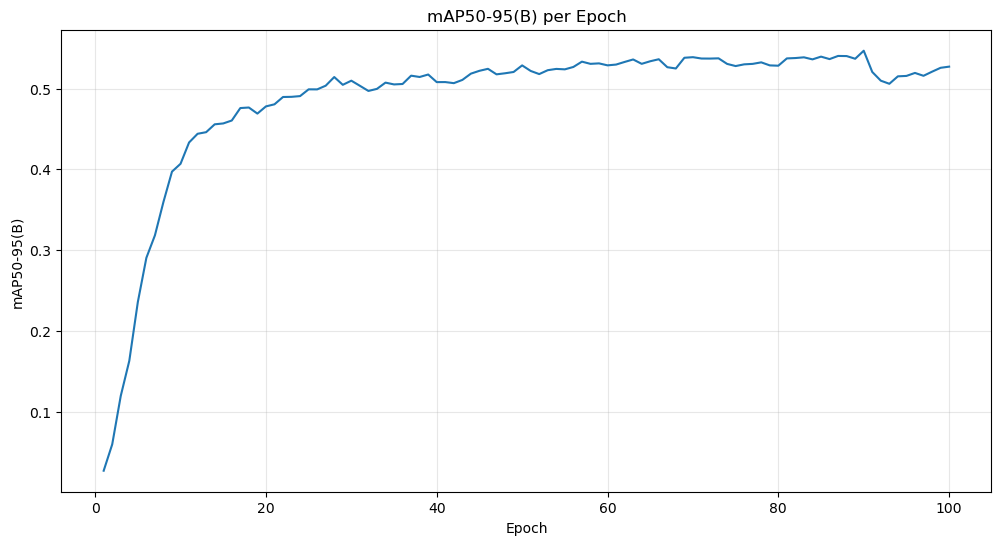

Best mAP50-95: 0.54682, at epoch: 90


In [16]:
# plot mAP50-95 across epochs

plt.figure(figsize=(12, 6))

plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'])

plt.title('mAP50-95(B) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('mAP50-95(B)')
plt.grid(True, alpha=0.3)
plt.show()

# get the best mAP50-95 score
idx = results_df['metrics/mAP50-95(B)'].idxmax() # index of max score
print(f'Best mAP50-95: {results_df.loc[idx, "metrics/mAP50-95(B)"]}, at epoch: {results_df.loc[idx, "epoch"]}')

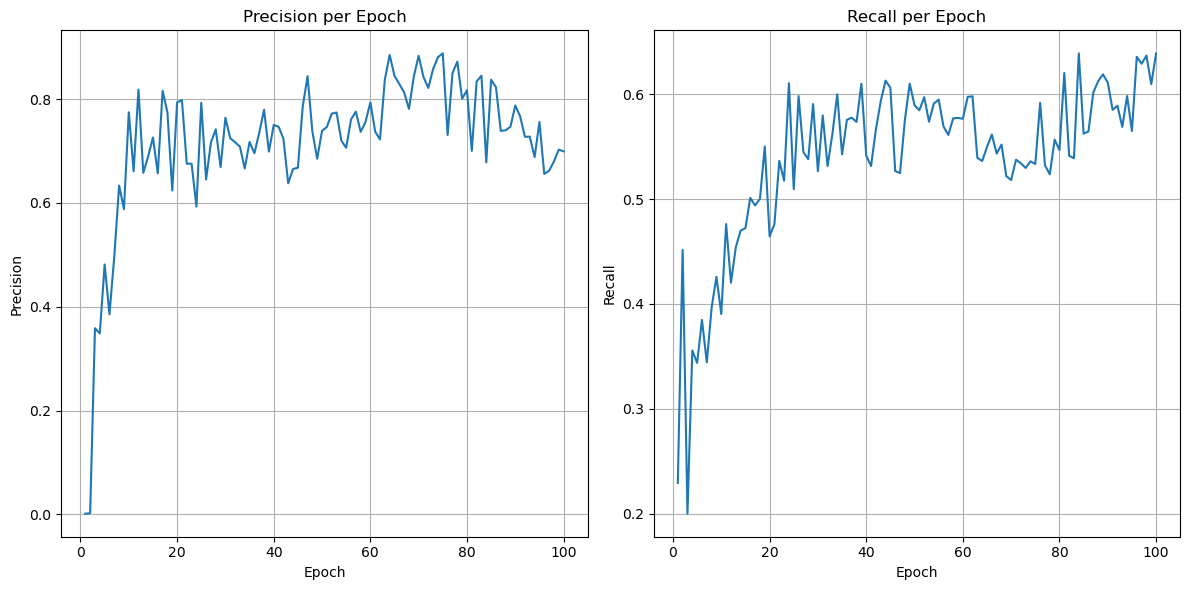

In [17]:
# plot precision and recall across epochs

fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 cols

ax[0].plot(results_df['epoch'], results_df['metrics/precision(B)'])
ax[0].set_title("Precision per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Precision")
ax[0].grid(True)

ax[1].plot(results_df['epoch'], results_df['metrics/recall(B)'])
ax[1].set_title("Recall per Epoch")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Recall")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# get model metrics
metrics = model.val(data=YOLO_YAML_PATH, plots=True)
print(metrics)

Ultralytics 8.4.6  Python-3.11.5 torch-2.2.2 CPU (AMD Ryzen 5 7520U with Radeon Graphics)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 414.5302.9 MB/s, size: 1345.6 KB)
val: Scanning C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\val.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111  0.0s
val: C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\val\052207bb-IMG_20251112_162822.jpg: corrupt JPEG restored and saved
val: C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\val\454ee7f7-IMG_20251112_162755.jpg: corrupt JPEG restored and saved
val: C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision fo

In [33]:
print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("mAP75:", metrics.box.map75)
print()

print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)
print()

names = metrics.names
for idx, name in names.items():
    print(f'{name}:')
    print(f'- Precision: {metrics.box.p[idx]}')
    print(f'- Recall: {metrics.box.r[idx]}\n')

mAP50-95: 0.5488024280010115
mAP50: 0.6798468183421882
mAP75: 0.610264051367277

Precision: [    0.94553      0.7893     0.68574      0.7254     0.72351     0.85606]
Recall: [    0.78378     0.54841         0.5     0.47368     0.56157         0.8]

Blind-Spot Mirror (Convex):
- Precision: 0.9455292197381873
- Recall: 0.7837837837837838

No Entry (One Way):
- Precision: 0.7892977344227778
- Recall: 0.5484136599646164

No Through Road (T-Sign):
- Precision: 0.6857409118439196
- Recall: 0.5

Pedestrian Crossing:
- Precision: 0.7254025448113324
- Recall: 0.47368421052631576

Roundabout Ahead:
- Precision: 0.7235068757232568
- Recall: 0.561565626894244

Stop:
- Precision: 0.8560583944471379
- Recall: 0.8



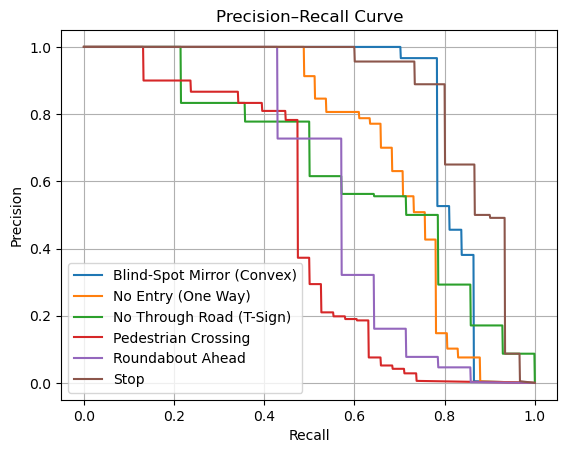

In [26]:
# plot Precision-Recall curve per class

recall = metrics.curves_results[0][0]
precision = metrics.curves_results[0][1]

names = metrics.names

plt.figure()
for i in range(precision.shape[0]):
    plt.plot(recall, precision[i], label=names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.legend()
plt.show()

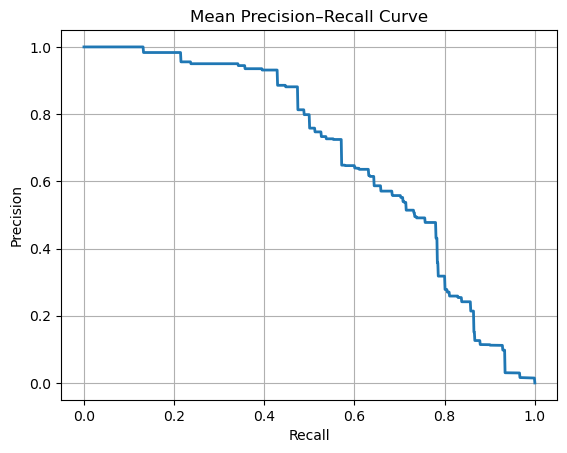

In [25]:
# plot mean precision-recall curve (all classes)

recall = metrics.curves_results[0][0]
precision = metrics.curves_results[0][1]

mean_precision = precision.mean(axis=0)

plt.figure()
plt.plot(recall, mean_precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Mean Precision–Recall Curve")
plt.grid(True)
plt.show()

In [36]:
print(metrics.confusion_matrix.to_df())

shape: (7, 8)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬──────┬────────────┐
│ Predicted      ┆ Blind_Spot_Mir ┆ No_Entry__One_ ┆ No_Through_Ro ┆ Pedestrian_Cr ┆ Roundabout_Ah ┆ Stop ┆ background │
│ ---            ┆ ror__Convex_   ┆ Way_           ┆ ad__T_Sign_   ┆ ossing        ┆ ead           ┆ ---  ┆ ---        │
│ str            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           ┆ f64  ┆ f64        │
│                ┆ f64            ┆ f64            ┆ f64           ┆ f64           ┆ f64           ┆      ┆            │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╪══════╪════════════╡
│ Blind_Spot_Mir ┆ 28.0           ┆ 0.0            ┆ 0.0           ┆ 0.0           ┆ 0.0           ┆ 0.0  ┆ 3.0        │
│ ror__Convex_   ┆                ┆                ┆               ┆               ┆               ┆      ┆            │
│ No_Entry__One_ ┆

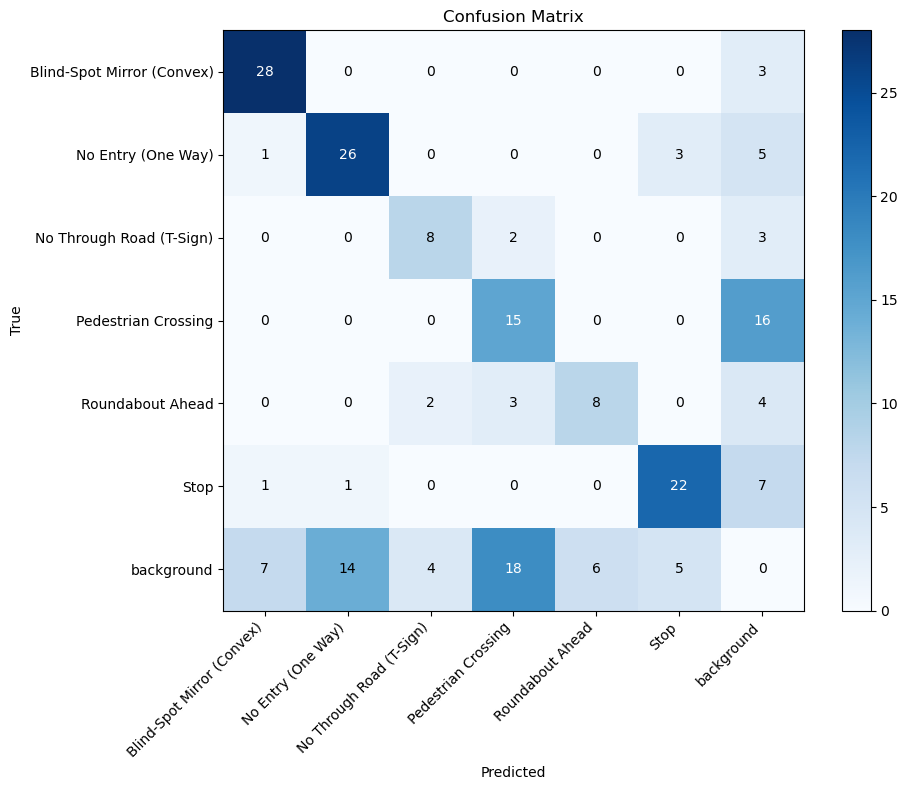

In [50]:
# plot confusion matrix

cm = metrics.confusion_matrix.matrix

names_dict = metrics.names
class_names = [names_dict[i] for i in range(len(names_dict))] + ["background"]

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# write numbers
thresh = cm.max() / 2  # for choosing text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, int(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Evaluate Model on Test Set

In [43]:
test_path = os.path.join(YOLO_DATA_PATH, 'images', 'test') # contains all test images

In [44]:
results = model.predict(source=test_path, save=True)


image 1/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\00abf266-WhatsApp_Image_2026-01-03_at_18.45.21_1.jpeg: 512x384 1 No Through Road (T-Sign), 1 Pedestrian Crossing, 299.4ms
image 2/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\00e70ac4-IMG_20251111_140913.jpg: 512x384 1 No Entry (One Way), 1 Roundabout Ahead, 202.9ms
image 3/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\0818c28d-20251108_012029.jpg: 512x384 2 No Entry (One Way)s, 201.5ms
image 4/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\0b62eb5a-IMG_20251111_145534.jpg: 512x384 (no detections), 175.7

image 35/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\5a615040-IMG_20251202_111908.jpg: 512x384 1 No Entry (One Way), 1 Stop, 140.7ms
image 36/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\5ac09409-IMG_20251210_143243.jpg: 512x384 1 Blind-Spot Mirror (Convex), 144.8ms
image 37/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\5ca04fcf-IMG_20251112_163537.jpg: 512x384 1 No Through Road (T-Sign), 137.2ms
image 38/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\5eaaea1e-IMG_20251111_142415.jpg: 512x384 1 Stop, 139.8ms
image 39/119 C:\Users\spite\Desktop\ARI3129 Adva

image 69/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\958cdeae-IMG_20251106_142220.jpg: 512x384 1 No Through Road (T-Sign), 153.2ms
image 70/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\99edf8bc-IMG_20251106_155403.jpg: 512x384 1 No Entry (One Way), 161.0ms
image 71/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\a11bbf9c-S7_front.jpg: 512x384 1 Stop, 159.8ms
image 72/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\a1320adb-IMG_20251106_141430.jpg: 512x384 1 No Entry (One Way), 159.2ms
image 73/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Ar

image 104/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\e6bab3dc-IMG_20251113_183845.jpg: 512x384 1 Stop, 132.3ms
image 105/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\e8226d79-WhatsApp_Image_2026-01-01_at_18.13.01_4.jpeg: 512x384 1 Roundabout Ahead, 139.1ms
image 106/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\e8da4b12-IMG_20251106_152038.jpg: 512x384 1 No Entry (One Way), 1 Roundabout Ahead, 1 Stop, 143.8ms
image 107/119 C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\images\test\e96a829f-IMG_20251106_155830.jpg: 512x384 1 No Entry (One Way), 1 Stop, 136.9ms
image 108/1

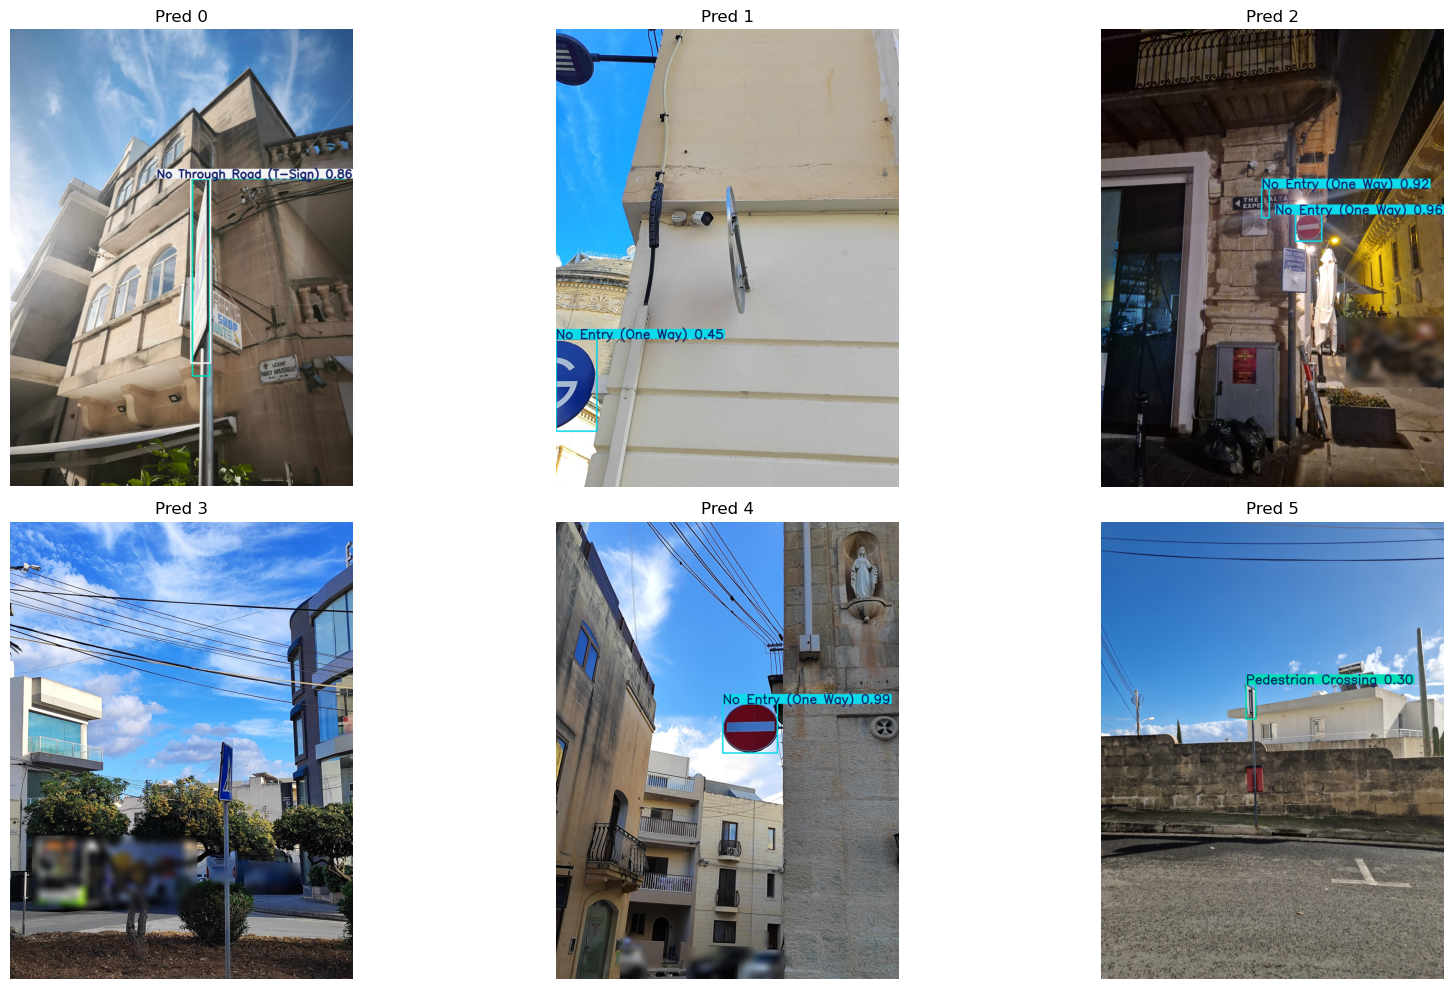

In [45]:
# plot the 1st 6 predictions
n = 6
cols = 3
rows = 2

plt.figure(figsize=(18, 10))

for i, r in enumerate(results[:n]):
    im_bgr = r.plot()
    im_rgb = im_bgr[..., ::-1]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(im_rgb)
    plt.axis("off")
    plt.title(f"Pred {i}")

plt.tight_layout()
plt.show()

In [47]:
total_images = len(results)
total_detections = 0
class_totals = Counter()

# count the number of total detections made
# and the total detections per each class
for r in results:
    if r.boxes is None or len(r.boxes) == 0:
        continue

    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    total_detections += len(cls_ids)
    class_totals.update([r.names[i] for i in cls_ids])

print(f"Images processed: {total_images}")
print(f"Total detections: {total_detections}\n")

print("Overall detections per sign type:")
for k, v in class_totals.items():
    print(f"- {k}: {v}")

Images processed: 119
Total detections: 151

Overall detections per sign type:
- No Through Road (T-Sign): 12
- Pedestrian Crossing: 20
- No Entry (One Way): 44
- Roundabout Ahead: 13
- Blind-Spot Mirror (Convex): 25
- Stop: 37


In [48]:
# evaluate on test set
test_metrics = model.val(data=YOLO_YAML_PATH, split="test")
print(test_metrics)

Ultralytics 8.4.6  Python-3.11.5 torch-2.2.2 CPU (AMD Ryzen 5 7520U with Radeon Graphics)
val: Fast image access  (ping: 0.30.0 ms, read: 422.1198.7 MB/s, size: 809.5 KB)
val: Scanning C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\test... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 383.8it/s 0.3s3s
val: New cache created: C:\Users\spite\Desktop\ARI3129 Advanced Computer Vision for Artificial Intelligence\Assignment\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.5s/it 27.7s3.9ss
                   all        119        168      0.652      0.569      0.596      0.496
Blind-Spot Mirror (Convex)         29         33      0.922      0.715      0.755      0.685
    No Entry (One Way)         41         49      0.697      0.571      0.621      0.5

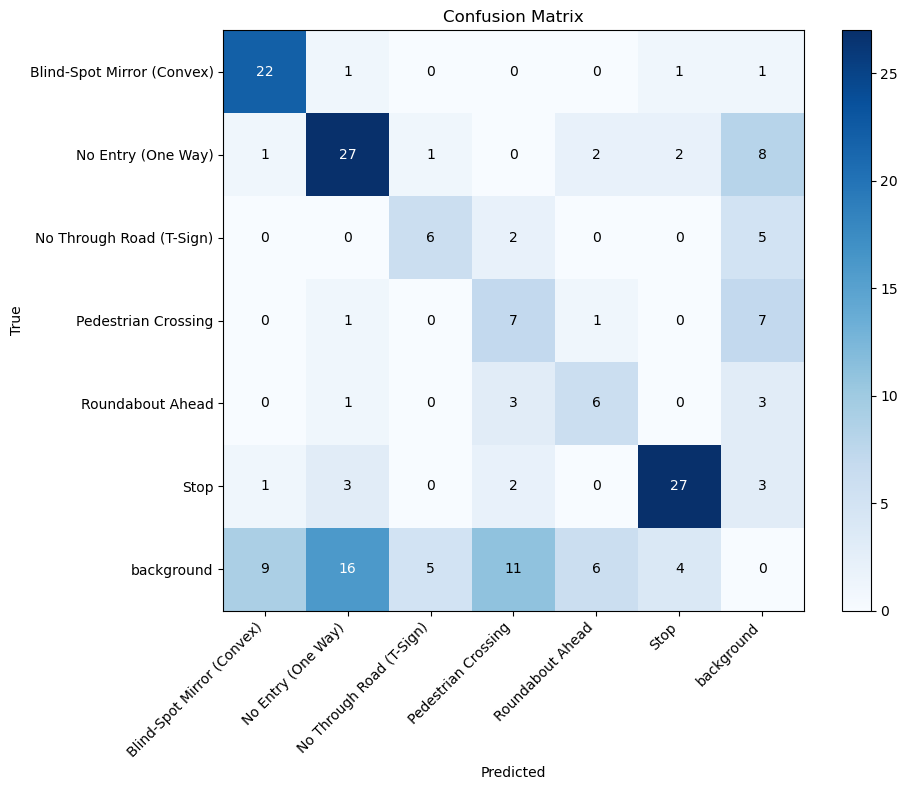

In [49]:
# plot confusion matrix

cm = test_metrics.confusion_matrix.matrix

names_dict = test_metrics.names
class_names = [names_dict[i] for i in range(len(names_dict))] + ["background"]

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

# write numbers
thresh = cm.max() / 2  # for choosing text color
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, int(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [51]:
print("mAP50-95:", test_metrics.box.map)
print("mAP50:", test_metrics.box.map50)
print("mAP75:", test_metrics.box.map75)
print()

print("Precision:", test_metrics.box.p)
print("Recall:", test_metrics.box.r)
print()

names = test_metrics.names
for idx, name in names.items():
    print(f'{name}:')
    print(f'- Precision: {test_metrics.box.p[idx]}')
    print(f'- Recall: {test_metrics.box.r[idx]}\n')

mAP50-95: 0.4957237994551147
mAP50: 0.5960134642130046
mAP75: 0.536727383355878

Precision: [    0.92178     0.69654     0.48307     0.56067      0.4698     0.77883]
Recall: [    0.71454     0.57143     0.54665        0.36         0.4     0.82353]

Blind-Spot Mirror (Convex):
- Precision: 0.9217841536428844
- Recall: 0.7145409070890122

No Entry (One Way):
- Precision: 0.6965371905352352
- Recall: 0.5714285714285714

No Through Road (T-Sign):
- Precision: 0.48306950893619455
- Recall: 0.5466506026950883

Pedestrian Crossing:
- Precision: 0.5606726261727664
- Recall: 0.36

Roundabout Ahead:
- Precision: 0.4698034662311902
- Recall: 0.4

Stop:
- Precision: 0.7788333504399975
- Recall: 0.8235294117647058

